In [ ]:
import numpy as np
import pandas as pd
import pdb 

# ACTG- Semi Synthetic Dataset - Informative


In [ ]:
#Refernce Taken from https://github.com/paidamoyo/counterfactual_survival_analysis
seed=31415
np.random.seed(seed)
data_frame = pd.read_csv('/content/ACTG175.csv', index_col=0)
to_drop = ['cens', 'days', 'arms', 'pidnum']

data_frame = data_frame.fillna(data_frame.median())

age_data = data_frame[['age']]
#print("age description:{}".format(age_data.describe()))
age_data =np.array(age_data).reshape(len(age_data))
#print(age_data.shape)
mu_age = np.mean(age_data)

cd40_data = data_frame[['cd40']]
#print("cd40_data description:{}".format(cd40_data.describe()))
cd40_data=np.array(cd40_data).reshape(len(cd40_data))
#print(cd40_data.shape)
mu_cd40 = np.mean(cd40_data)

x_data =  data_frame.drop(labels=to_drop, axis=1)
#print("covariate description:{}".format(x_data.describe()))
x_data =np.array(x_data).reshape(x_data.shape)
#print(x_data.shape)

beta_one = [ 0.0026987044,  0.0094957416, -0.2047708817, -0.0518243280, -0.2168722467,  0.0076266828, -0.0796099695,  
            0.6258748940, 0, 0.0009670592, -1.0101809693, -0.4038655688, -1.5959739338, -0.0563572096, 0.5244218189,    
            0,  0.2280296997,  0.0035548596, -0.0047974742, -0.0121293815, -1.0625208970, -0.0004266264,0.0005844290 ]
beta_one = np.array(beta_one)
#print("beta_one: ", beta_one.shape)
assert(beta_one.shape[0] == x_data.shape[1])
beta_zero = [1.148569e-02,  3.896347e-03, -3.337743e-02, -1.215442e-01, -6.036002e-01,  4.563380e-03, -5.217492e-02,
             1.414948e+00, 0,  9.294612e-06, 7.863787e-02,  4.756738e-01, -7.807835e-01, -1.766999e-01,  1.622865e-01,
             0,  1.551692e-01,  2.793350e-03, -6.417969e-03, -9.856514e-03,  -1.127284e+00, 
             2.247806e-04,  1.952943e-04] 
beta_zero = np.array(beta_zero)
#print("beta_zero: ", beta_zero.shape)
assert(beta_zero.shape[0] == x_data.shape[1])


def sigmoid(a):
    return 1/(1 + np.exp(-a))


N = x_data.shape[0]
T_F = np.zeros(N) #Time-to-event Factual
T_CF = np.zeros(N) #Time-to-event CounterFactual
C_F = np.zeros(N)  #Outcome Factual
C_CF = np.zeros(N) 
Y_F = np.zeros(N)  #Outcome Factual
Y_CF = np.zeros(N) #Outcome CounterFactual
delta_F = np.zeros(N) 
delta_CF = np.zeros(N) 
W =  np.zeros(N) #Treatment Indicator
prop =  np.zeros(N) 

time = 'days'

lamd_zero = 6 * 1e-4
lamd_one = 6 * 1e-4

#########################
#New variables introduced lamd_0_c and lamd_1_c for making Censoring Time dependent on features
lamd_zero_c = 8.8 * 1e-4 
lamd_one_c = 8.8 * 1e-4
alpha_c = 0.0050
#########################

alpha = 0.0055

U_0 =  np.random.uniform(0,1, size=(N))
U_1 =  np.random.uniform(0,1, size=(N))

gamma = -30
b_zero = 0

########################################################################
data = 'info' #{'info', 'non_info'} Dataset Generation for Informative/Non-Informative Cenosring

if data == 'non_info': 
   c_mean_time = 1000 # mean censoring time
   c_std_time = 100 # std censoring time
   C = np.random.normal(c_mean_time, c_std_time, size=(N))


for i in range(N):
    
    pos_age_i = age_data[i]
    beta_i = gamma * ((pos_age_i - mu_age) + (cd40_data[i]-mu_cd40))# counfounding
    
    balance = 1.5 # parameter to balance
    prop_i = 1/balance * (0.3 + sigmoid(beta_i))
    prop[i] = prop_i
    
    W_i = np.random.binomial(n=1, p=prop_i, size=1)[0]
    W[i] = W_i
    
    cov_eff_T_0 = lamd_zero * np.exp(np.dot(x_data[i], beta_zero))
    cov_eff_T_1 = lamd_one * np.exp(np.dot(x_data[i], beta_one))
    
    ###changed
    cov_eff_C_0 = lamd_zero_c * np.exp(np.dot(x_data[i], beta_zero))
    cov_eff_C_1 = lamd_one_c * np.exp(np.dot(x_data[i], beta_one))
    ####

    stoch_0 = alpha * np.log(U_0[i])
    stoch_1 = alpha * np.log(U_1[i])
    
    ####changed
    stoch_0_c = alpha_c * np.log(U_0[i])
    stoch_1_c = alpha_c * np.log(U_1[i])
    ###

    T_1_i = 1/alpha * np.log(1 - stoch_1/cov_eff_T_1) + b_zero
    T_0_i = 1/alpha * np.log(1 - stoch_0/cov_eff_T_0)  
    
    T_F_i =  W_i * T_1_i + (1-W_i) * T_0_i
    T_CF_i = (1-W_i) * T_1_i + W_i * T_0_i
    
    if data == 'info':
      # C_1_i = np.exp(np.random.normal(np.log(T_1_i), 0.01, size=(1)))
      # C_0_i = np.exp(np.random.normal(np.log(T_0_i), 0.01, size=(1)))
      C_1_i = 1/alpha_c * np.log(1 - stoch_1_c/cov_eff_C_1) + b_zero
      C_0_i = 1/alpha_c * np.log(1 - stoch_0_c/cov_eff_C_0)

      
      C_F_i =  W_i * C_1_i + (1-W_i) * C_0_i
      C_CF_i = (1-W_i) * C_1_i + W_i * C_0_i

      Y_F_i = min(T_F_i, C_F_i)
      Y_CF_i = min(T_CF_i, C_CF_i)
    
      delta_F_i = T_F_i <= C_F_i
      delta_F[i] = delta_F_i
    
      delta_CF_i = T_CF_i <= C_CF_i
      delta_CF[i] = delta_CF_i 
    
      T_F[i] = T_F_i
      T_CF[i] = T_CF_i
    
      C_F[i] = C_F_i
      C_CF[i] = C_CF_i

      Y_F[i] = Y_F_i
      Y_CF[i] = Y_CF_i

    elif data == 'non_info':
      C_i = C[i]

      Y_F_i = min(T_F_i, C_i)
      Y_CF_i = min(T_CF_i, C_i)
    
      delta_F_i = T_F_i <= C_i
      delta_F[i] = delta_F_i
    
      delta_CF_i = T_CF_i <= C_i
      delta_CF[i] = delta_CF_i 
    
      T_F[i] = T_F_i
      T_CF[i] = T_CF_i
    
      Y_F[i] = Y_F_i
      Y_CF[i] = Y_CF_i

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:42: RuntimeWarning: overflow encountered in exp


In [ ]:
####Saving Data Frame
df = pd.DataFrame(x_data)
if data=='non_info':
  df = df.assign(W =  W, y_f = Y_F,e_f =  delta_F, t_f =  T_F,y_cf =  Y_CF, e_cf =  delta_CF, t_cf = T_CF)
elif data=='info':
  df = df.assign(W =  W, y_f = Y_F,e_f =  delta_F, t_f =  T_F, c_f = C_F ,y_cf =  Y_CF, e_cf =  delta_CF, t_cf = T_CF, c_cf =  C_CF)
df.to_csv("actg_semi_{}_new.csv".format(data), index=False)


Text(0.5, 1.0, 'Censoring Time - Counterfactual')

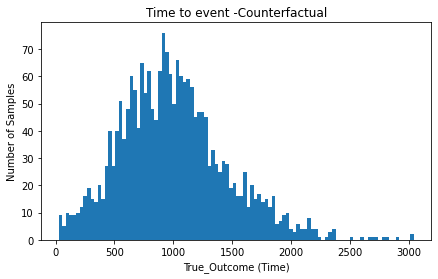

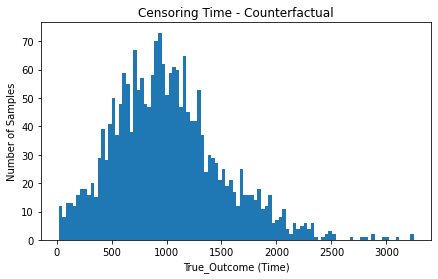

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize =(7, 4)) 
ax.hist(T_CF,bins=100) 
plt.xlabel("True_Outcome (Time)") 
plt.ylabel("Number of Samples")
plt.title('Time to event -Counterfactual')
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize =(7, 4)) 
ax.hist(C_CF,bins=100) 
plt.xlabel("True_Outcome (Time)") 
plt.ylabel("Number of Samples")
plt.title('Censoring Time - Counterfactual')

In [ ]:
unique, counts = np.unique(delta_F, return_counts=True)
print('Number of Censored samples', counts[0])
print('Number of uncesnored samples', counts[1])
unique, counts = np.unique(W, return_counts=True)
print('Number of Control samples', counts[0])
print('Number of Treated samples', counts[1])
df['e_f'] = delta_F
df['e_cf'] = delta_CF
df['y_f'] = Y_F
df['y_cf'] = Y_CF

Number of Censored samples 940
Number of uncesnored samples 1199
Number of Control samples 950
Number of Treated samples 1189


In [ ]:
np.save('covariates', x_data)
np.save('treatment', W)
data_F = {'y_f': Y_F, 'e_f': delta_F, 't_f': T_F,'y_cf': Y_CF, 'e_cf': delta_CF,'t_cf': T_CF}
df = pd.DataFrame.from_dict(data_F)
df.to_csv('event_pairs.csv', index=False)

# Synthetic Dataaset

Non-Informative Censoring

In [ ]:
import random
import numpy as np 
import pandas as pd
np.random.seed(1234)
random.seed(1234)
mu, sigma = 0, 1 # mean and standard deviation
n = 5000 #Total No. of Patients 
X1,X2,X3 = [], [], []#Three 4 dimensional vector features
for i in range(n):
    X1.append(np.random.normal(mu, sigma,4))
    X2.append(np.random.normal(mu, sigma,4))
    X3.append(np.random.normal(mu, sigma,4))
beta_0, beta_1 = [], [] #Mean Parameters for exponential distribution
for i in range(n):
    gamma = np.array([10,10,10,10])
    gamma1 = np.array([10,10,10,10]) 
    beta_0.append(np.square(np.dot(gamma.reshape((1,4)),X3[i].reshape((4,1)))) + np.dot(gamma.reshape((1,4)),X1[i].reshape((4,1))))
    beta_1.append(np.square(np.dot(gamma1.reshape((1,4)),X3[i].reshape((4,1)))) + np.dot(gamma1.reshape((1,4)),X2[i].reshape((4,1))))
X1 = np.asarray(X1)
X2 = np.asarray(X2)
X3 = np.asarray(X3)
d = { 
    'feature1_1' :X1[:,0],'feature1_2' :X1[:,1],'feature1_3' :X1[:,2],'feature1_4' :X1[:,3],
     'feature2_1' :X2[:,0],'feature2_2' :X2[:,1],'feature2_3' :X2[:,2],'feature2_4' :X2[:,3],
     'feature3_1' :X3[:,0],'feature3_2' :X3[:,1],'feature3_3' :X3[:,2],'feature3_4' :X3[:,3],
     }
df = pd.DataFrame(data = d)
T0 = [] #Outcome Variable Time for Treatment 0
T1 = [] #Outcome Variable Time for Treatment 1
for i in range(n):
    T0.append(int(np.random.exponential(abs(float(beta_0[i])),1)))
    T1.append(int(np.random.exponential(abs(float(beta_1[i])),1)))
T0_CLIP = np.clip(T0, 3,max(T0))
T1_CLIP = np.clip(T1,3,max(T1))
W = np.zeros((len(df)))
for i in range(len(df)):
  if  df['feature3_1'][i] < 1 and df['feature3_1'][i] > -1 and df['feature3_2'][i] < 1 and df['feature3_2'][i] >0:
    W[i] = 1
df['treatment'] = W
c_mean_time = 500 # mean censoring time #{1000,500,200,}
c_std_time = 50 # std censoring time #{,50,50}
#censoring {,49.9,31.28}
U_0 =  np.random.uniform(0,1, size=(n))
U_1 =  np.random.uniform(0,1, size=(n))
C = np.random.normal(c_mean_time, c_std_time, size=(n))
TF = W*T1_CLIP + (1-W)*T0_CLIP
TCF= (1-W)*T1_CLIP + W*T0_CLIP
YF = []
YCF = []
delta_F = []
delta_CF = []
for i in range(n):  
  C_i = C[i]
  YF.append(min(TF[i], C[i]))
  YCF.append(min(TCF[i], C[i]))
  delta_F.append(int(TF[i] <=C[i]))
  delta_CF.append(int(TCF[i] <=C[i]))
unique, counts = np.unique(delta_F, return_counts=True)
print('Number of Censored samples', counts[0])
print('Number of uncesnored samples', counts[1])
unique, counts = np.unique(W, return_counts=True)
print('Number of Control samples', counts[0])
print('Number of Treated samples', counts[1])
df['e_f'] = delta_F
df['e_cf'] = delta_CF
df['y_f'] = YF
df['y_cf'] = YCF

Number of Censored samples 1063
Number of uncesnored samples 3937
Number of Control samples 3846
Number of Treated samples 1154


Synthetic - Informative Censoring (Old Technique of Data Generation)

In [ ]:
# seed=31415
# np.random.seed(seed)
# mu, sigma = 1, 1   #for informative {1,1} ,for non informative{0,1}  mean and standard deviation  
# N = 5000 #Total No. of Patients 
# data = 'info'   #{'info', 'non_info'} Dataset Generation Select 'info' for  Informative and 'non_info' for Non-Informative Cenosring

# X1,X2,X3 = [], [], []#Three 4 dimensional vector features
# for i in range(N):
#     X1.append(np.random.normal(mu, sigma,4))
#     X2.append(np.random.normal(mu, sigma,4))
#     X3.append(np.random.normal(mu, sigma,4))

# X1 = np.asarray(X1)
# X2 = np.asarray(X2)
# X3 = np.asarray(X3)
# d = { 
#     'feature1_1' :X1[:,0],'feature1_2' :X1[:,1],'feature1_3' :X1[:,2],'feature1_4' :X1[:,3],
#      'feature2_1' :X2[:,0],'feature2_2' :X2[:,1],'feature2_3' :X2[:,2],'feature2_4' :X2[:,3],
#      'feature3_1' :X3[:,0],'feature3_2' :X3[:,1],'feature3_3' :X3[:,2],'feature3_4' :X3[:,3],
#      }
# df = pd.DataFrame(data = d)

# x_data = np.array(df)

# gamma = np.array([10,10,10,10]) # For Informative-np.array([1,1,1,1]), Non-informative [10,10,10,10]
# T_F = np.zeros(N) #Time-to-event Factual
# T_CF = np.zeros(N) #Time-to-event CounterFactual
# C_F = np.zeros(N)  #Censoring Time Factual
# C_CF = np.zeros(N) #Censoring Time Counterfactual
# Y_F = np.zeros(N)  #Outcome Factual
# T_0  = np.zeros(N)
# T_1 = np.zeros(N)
# Y_CF = np.zeros(N) #Outcome CounterFactual
# delta_F = np.zeros(N) #Event/Censoring Indicator Factual 
# delta_CF = np.zeros(N) #Event/Censoring Indicator CounterFactual 
# W = np.zeros(N) #Treatment Variable

# #####################
# for i in range(N):
#   beta_0_i = np.square(np.dot(gamma.reshape((1,4)),X3[i].reshape((4,1)))) + np.dot(gamma.reshape((1,4)),X1[i].reshape((4,1)))
#   beta_1_i = np.square(np.dot(gamma.reshape((1,4)),X3[i].reshape((4,1)))) + np.dot(gamma.reshape((1,4)),X2[i].reshape((4,1)))
#   T_0_i = np.random.exponential(abs(float(beta_0_i)),1)
#   T_1_i = np.random.exponential(abs(float(beta_1_i)),1)


#   if  df['feature3_1'][i] < 3 and df['feature3_1'][i] > 1 and df['feature3_2'][i] < 5 and df['feature3_2'][i] >1: #for informative
#   #if  df['feature3_1'][i] < 1 and df['feature3_1'][i] > -1 and df['feature3_2'][i] < 1 and df['feature3_2'][i] >0:  #for non-informative
#     W[i] = 1
#   else:
#     W[i] = 0

#   T_F_i =  W[i] * T_1_i + (1-W[i]) * T_0_i
#   T_CF_i = (1-W[i])* T_1_i + W[i] * T_0_i
#   T_0[i] = T_0_i
#   T_1[i] = T_1_i
#   T_F[i] = T_F_i
#   T_CF[i] = T_CF_i

# ######################
# if data == 'non_info': 
#    c_mean_time = 6 # mean censoring time #1000,500
#    c_std_time = 0.01 # std censoring time #100,50
#    C = np.exp(np.random.normal(np.log(c_mean_time), c_std_time, size=(N)))
#    print('Non Informative Cesnoring')
# elif data == 'info':
#   print('Informative Censoring')
# else:
#   prit('Type of Censoring Not defined')

# #####################
# for i in range(N):

#   if data == 'info':

#     C_1_i = np.exp(np.random.normal(np.log(T_1[i]), 0.01, size=(1)))
#     C_0_i = np.exp(np.random.normal(np.log(T_0[i]), 0.01, size=(1)))
  

#     C_F_i =  W[i] * C_1_i + (1-W[i]) * C_0_i
#     C_CF_i = (1-W[i]) * C_1_i + W[i] * C_0_i

#     Y_F_i = min(T_F[i], C_F_i)
#     Y_CF_i = min(T_CF[i], C_CF_i)
    
#     delta_F_i = T_F[i] <= C_F_i
#     delta_F[i] = delta_F_i
    
#     delta_CF_i = T_CF[i] <= C_CF_i
#     delta_CF[i] = delta_CF_i 
    
#     C_F[i] = C_F_i
#     C_CF[i] = C_CF_i

#     Y_F[i] = Y_F_i
#     Y_CF[i] = Y_CF_i

#   elif data == 'non_info':
#     C_i = C[i]

#     Y_F_i = min(T_F[i], C_i)
#     Y_CF_i = min(T_CF[i], C_i)
    
#     delta_F_i = T_F[i] <= C_i
#     delta_F[i] = delta_F_i
    
#     delta_CF_i = T_CF[i] <= C_i
#     delta_CF[i] = delta_CF_i 
    
#     Y_F[i] = Y_F_i
#     Y_CF[i] = Y_CF_i

#   else:
#     print('DATA not defined')



In [ ]:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize =(10, 7)) 
# ax.hist(C_CF,bins=100) 
# plt.xlabel("True_Outcome (Time)") 
# plt.ylabel("Number of Samples")

# Synthetic Dataset- Informative Censoring (New)

Three 4-dimensional covariates are sampled from normal distribution: \\
$\mathbf{x}_1^{(i)}, \mathbf{x}_2^{(i)}, \mathbf{x}_3^{(i)} \sim \mathcal{N}(1,1)$ 

Time-to-event Generation: \\
$T^{(i)}_0 \sim \exp\Big(\big|(\gamma_1^T \mathbf{x}_3^{(i)})^2 + \gamma_1^T \mathbf{x}_1^{(i)}\big|\Big)$,
$T^{(i)}_1 \sim \exp\Big(\big|(\gamma_1^T \mathbf{x}_3^{(i)})^2 + \gamma_1^T \mathbf{x}_2^{(i)}\big|\Big)$


Censoring Time Generation: \\
$C^{(i)}_0 \sim \exp\Big(\big|(\gamma_2^T \mathbf{x}_3^{(i)}) + \gamma_2^T \mathbf{x}_1^{(i)}\big|\Big)$,
$C^{(i)}_1 \sim \exp\Big(\big|(\gamma_2^T \mathbf{x}_3^{(i)}) + \gamma_2^T \mathbf{x}_2^{(i)}\big|\Big)$


where,
$\gamma_1,\gamma_2 = [5,5,5,5] $ and $[80,80,80,80] $respectively  for informative censoring.

In [ ]:
#changed
import pdb
seed=31415
np.random.seed(seed)
mu, sigma = 1, 1
mu1,sigma1 = 2,1   #for informative {1,1} ,for non informative{0,1}  mean and standard deviation  
N = 5000 #Total No. of Patients 
data = 'info'   #{'info', 'non_info'} Dataset Generation Select 'info' for  Informative and 'non_info' for Non-Informative Cenosring

X1,X2,X3 = [], [], []#Three 4 dimensional vector features
for i in range(N):
    X1.append(np.random.normal(mu, sigma,4))
    X2.append(np.random.normal(mu, sigma,4))
    X3.append(np.random.normal(mu, sigma,4))

X1 = np.asarray(X1)
X2 = np.asarray(X2)
X3 = np.asarray(X3)
d = { 
    'feature1_1' :X1[:,0],'feature1_2' :X1[:,1],'feature1_3' :X1[:,2],'feature1_4' :X1[:,3],
     'feature2_1' :X2[:,0],'feature2_2' :X2[:,1],'feature2_3' :X2[:,2],'feature2_4' :X2[:,3],
     'feature3_1' :X3[:,0],'feature3_2' :X3[:,1],'feature3_3' :X3[:,2],'feature3_4' :X3[:,3],
     }
df = pd.DataFrame(data = d)

x_data = np.array(df)

gamma = np.array([5,5,5,5]) # For Informative-np.array([5,5,5,5]), Non-informative [10,10,10,10]
T_F = np.zeros(N) #Time-to-event Factual
T_CF = np.zeros(N) #Time-to-event CounterFactual
C_F = np.zeros(N)  #Censoring Time Factual
C_CF = np.zeros(N) #Censoring Time Counterfactual
Y_F = np.zeros(N)  #Outcome Factual
T_0  = np.zeros(N)
T_1 = np.zeros(N)
Y_CF = np.zeros(N) #Outcome CounterFactual
delta_F = np.zeros(N) #Event/Censoring Indicator Factual 
delta_CF = np.zeros(N) #Event/Censoring Indicator CounterFactual 
W = np.zeros(N) #Treatment Variable

#####################
for i in range(N):
  beta_0_i = np.square(np.dot(gamma.reshape((1,4)),X3[i].reshape((4,1)))) + np.dot(gamma.reshape((1,4)),X1[i].reshape((4,1)))
  beta_1_i = np.square(np.dot(gamma.reshape((1,4)),X3[i].reshape((4,1)))) + np.dot(gamma.reshape((1,4)),X2[i].reshape((4,1)))
  T_0_i = np.random.exponential(abs(float(beta_0_i)),1)
  T_1_i = np.random.exponential(abs(float(beta_1_i)),1)


  if  df['feature3_1'][i] < 3 and df['feature3_1'][i] > 1 and df['feature3_2'][i] < 5 and df['feature3_2'][i] >1: #for informative
  #if  df['feature3_1'][i] < 1 and df['feature3_1'][i] > -1 and df['feature3_2'][i] < 1 and df['feature3_2'][i] >0:  #for non-informative
    W[i] = 1
  else:
    W[i] = 0

  T_F_i =  W[i] * T_1_i + (1-W[i]) * T_0_i
  T_CF_i = (1-W[i])* T_1_i + W[i] * T_0_i
  T_0[i] = T_0_i
  T_1[i] = T_1_i
  T_F[i] = T_F_i
  T_CF[i] = T_CF_i

######################
if data == 'non_info': 
   c_mean_time = 6 # mean censoring time #1000,500
   c_std_time = 0.01 # std censoring time #100,50
   C = np.exp(np.random.normal(np.log(c_mean_time), c_std_time, size=(N)))
   print('Non Informative Cesnoring')
elif data == 'info':
  print('Informative Censoring')
else:
  prit('Type of Censoring Not defined')

#####################
for i in range(N):

  if data == 'info':

    # C_1_i = np.exp(np.random.normal(np.log(T_1[i]), 0.01, size=(1)))
    # C_0_i = np.exp(np.random.normal(np.log(T_0[i]), 0.01, size=(1)))
    #Changed 
    gamma1 = np.array([80,80,80,80])
                      
    
    #pdb.set_trace()
    beta_0_i = np.dot(gamma1.reshape((1,4)),X3[i].reshape((4,1))) + np.dot(gamma1.reshape((1,4)),X1[i].reshape((4,1)))
    beta_1_i = np.dot(gamma1.reshape((1,4)),X3[i].reshape((4,1))) + np.dot(gamma1.reshape((1,4)),X2[i].reshape((4,1)))
    C_0_i = np.random.exponential(abs(float(beta_0_i) ),1)
    C_1_i = np.random.exponential(abs(float(beta_1_i) ),1)
    
    
    C_F_i =  W[i] * C_1_i + (1-W[i]) * C_0_i
    C_CF_i = (1-W[i]) * C_1_i + W[i] * C_0_i

    Y_F_i = min(T_F[i], C_F_i)
    Y_CF_i = min(T_CF[i], C_CF_i)
    
    delta_F_i = T_F[i] <= C_F_i
    delta_F[i] = delta_F_i
    
    delta_CF_i = T_CF[i] <= C_CF_i
    delta_CF[i] = delta_CF_i 
    
    C_F[i] = C_F_i
    C_CF[i] = C_CF_i

    Y_F[i] = Y_F_i
    Y_CF[i] = Y_CF_i

  elif data == 'non_info':
    C_i = C[i]

    Y_F_i = min(T_F[i], C_i)
    Y_CF_i = min(T_CF[i], C_i)
    
    delta_F_i = T_F[i] <= C_i
    delta_F[i] = delta_F_i
    
    delta_CF_i = T_CF[i] <= C_i
    delta_CF[i] = delta_CF_i 
    
    Y_F[i] = Y_F_i
    Y_CF[i] = Y_CF_i

  else:
    print('DATA not defined')

unique, counts = np.unique(delta_F, return_counts=True)
print('Number of Censored samples', counts[0])
print('Number of uncesnored samples', counts[1])
unique, counts = np.unique(W, return_counts=True)
print('Number of Control samples', counts[0])
print('Number of Treated samples', counts[1])
df['e_f'] = delta_F
df['e_cf'] = delta_CF
df['y_f'] = Y_F
df['y_cf'] = Y_CF

Informative Censoring
Number of Censored samples 1949
Number of uncesnored samples 3051
Number of Control samples 3798
Number of Treated samples 1202


Text(0.5, 1.0, 'Censoring Time - factual')

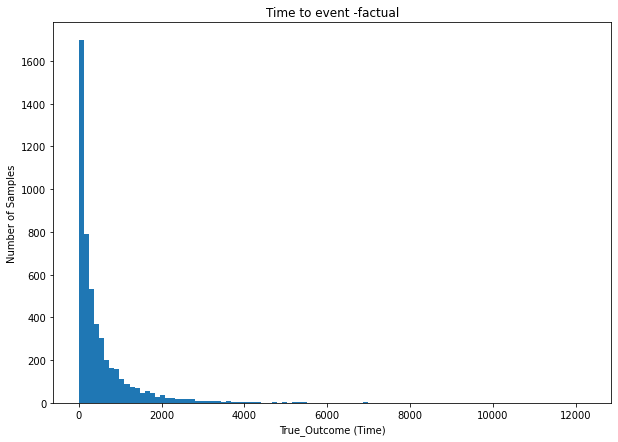

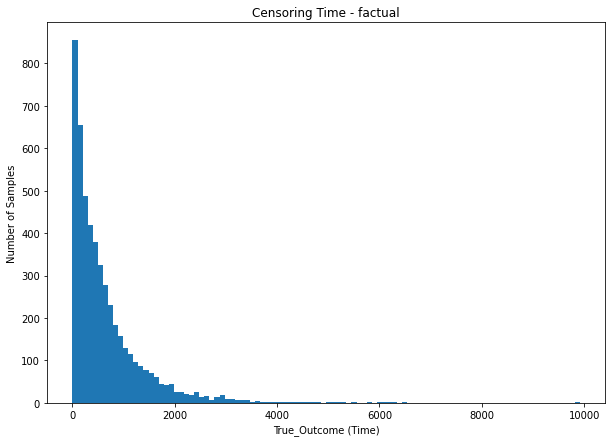

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize =(10, 7)) 
ax.hist(T_F,bins=100) 
plt.xlabel("True_Outcome (Time)") 
plt.ylabel("Number of Samples")
plt.title('Time to event -factual')
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize =(10, 7)) 
ax.hist(C_F,bins=100) 
plt.xlabel("True_Outcome (Time)") 
plt.ylabel("Number of Samples")
plt.title('Censoring Time - factual')

In [ ]:
###Saving Data Frame
if data=='non_info':
  df = df.assign(treatment =  W, y_f = Y_F,e_f =  delta_F, t_f =  T_F,y_cf =  Y_CF, e_cf =  delta_CF, t_cf = T_CF)
elif data=='info':
  df = df.assign(treatment =  W, y_f = Y_F,e_f =  delta_F, t_f =  T_F, c_f = C_F ,y_cf =  Y_CF, e_cf =  delta_CF, t_cf = T_CF, c_cf =  C_CF)
df.to_csv("synthetic_{}.csv".format(data), index=False)

In [ ]:
# np.save('covariates', x_data)
# np.save('treatment', W)
# data_F = {'y_f': Y_F, 'e_f': delta_F, 't_f': T_F, 'y_cf': Y_CF, 'e_cf': delta_CF, 't_cf': T_CF}
# df1 = pd.DataFrame.from_dict(data_F)
# df1.to_csv('event_pairs.csv', index=False)

# Metabric Dataset

In [ ]:
# %cd /content/drive/MyDrive/Colab Notebooks/Thesis/METABRIC Dataset
# import pandas as pd
# import numpy as np
# import pickle
# import pdb

# def interpolate(S,vartype):
# 	S_non_nan = S[~S.isna()]
# 	if (vartype == 'real'):
# 		S = S.fillna(S_non_nan.mean())
# 	if (vartype == 'int'):
# 		S = S.fillna(int(S_non_nan.mean()))
# 	if (vartype == 'cat'):
# 		S = S.fillna(S_non_nan.mode()[0])
# 	#pdb.set_trace()
# 	return S

# fn = "brca_metabric_clinical_data.tsv"
# treatment = 'Chemotherapy' #{'Type of Breast Surgery', 'Chemotherapy' , 'Hormone Therapy', 'Radio Therapy'}
# time = 'Overall Survival (Months)'
# censored = 'Overall Survival Status'
# outfile = open('outdata','wb')

# df = pd.read_csv(fn,sep = "\t")

# df.dropna(subset = ['Chemotherapy'],inplace=True)

# ####### Step 1
# ####### Drop 'Study ID', 'Sample ID', 'Sample Type' , 'Sex', 'Cohorot'
# colsAnalyzed = ['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed', 'Cellularity','Chemotherapy','Pam50 + Claudin-low subtype','ER status measured by IHC','ER Status','Neoplasm Histologic Grade','HER2 status measured by SNP6','HER2 Status','Tumor Other Histologic Subtype',
# 'Hormone Therapy','Inferred Menopausal State','Integrative Cluster', 'Primary Tumor Laterality', 'Lymph nodes examined positive','Mutation Count', 
# 'Nottingham prognostic index', 'Oncotree Code', 'PR Status', 'Radio Therapy', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage','Overall Survival (Months)',
# 'Overall Survival Status']

# colType = ['real','cat','cat','cat','cat','cat','cat',
# 'cat','cat','cat','cat','cat','cat',
# 'cat','cat','cat','cat','cat','int',
# 'real','cat','cat','cat','cat','int','cat','real',
# 'cat']

# df = df[colsAnalyzed]

# ####### Step 2
# ####### Replace Nan in continuous valued column using mean & categorical column with mode as in Deep-Hit paper

# for i,cols in enumerate(colsAnalyzed):
# 	vartype = colType[i]
# 	df[cols] =interpolate(df[cols],vartype)
 
# ###### Step 3
# ####### Replace categorical columns with One-Hot encoding

# for i,cols in enumerate(colsAnalyzed):
# 	if (colType[i] == 'cat'):
# 		one_hot = pd.get_dummies(df[cols])
# 		if (cols == censored):
# 			df[cols] = df[cols].str.split(':',expand=True)
# 			#pdb.set_trace()
			
# 		if (cols == treatment):
# 			df[cols] = df[cols] == df[cols].unique()[0]
# 			#pdb.set_trace()
# 		if (not(cols in [censored,treatment])):
# 			one_hot.columns = [cols] * df[cols].unique().shape[0]
# 			df = df.drop(cols,axis = 1)
# 			df = df.join(one_hot)

# #### Step 4 
# #### change to 'x','t','e','y' format

# data = {}

# colsAnalyzed.remove(treatment)

# data['t'] = df[treatment]

# colsAnalyzed.remove(time)
# data['y'] = df[time]

# colsAnalyzed.remove(censored)
# data['e'] = df[censored] ## 0 for Living, 1 for deceased

# data['x'] = df[colsAnalyzed]


/content/drive/MyDrive/Colab Notebooks/Thesis/METABRIC Dataset


# Dataset Analysis

In [ ]:
unique, counts = np.unique(df['treatment'], return_counts=True)
print('Number of Control samples', counts[0])
print('Number of Treated samples', counts[1])
unique, counts = np.unique(df['e_f'], return_counts=True)
print('Number of Factual Cesnored samples', counts[0])
print('Number of Factual Uncensored samples', counts[1])
# unique, counts = np.unique(delta_CF, return_counts=True)
# print('Number of Counterfactual Cesnored samples', counts[0])
# print('Number of Counterfactual Uncensored samples', counts[1])

Number of Control samples 3798
Number of Treated samples 1202
Number of Factual Cesnored samples 2508
Number of Factual Uncensored samples 2492


Text(0.5, 1.0, 'Factual- Complete Data')

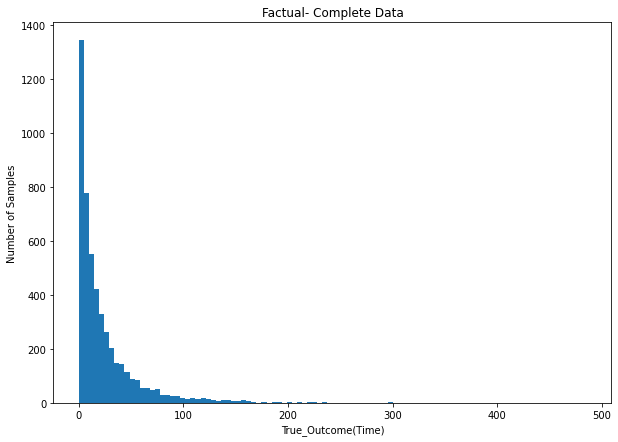

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize =(10, 7)) 
ax.hist(T_F,bins=100) 
plt.xlabel("True_Outcome(Time)") 
plt.ylabel("Number of Samples")
plt.title('Factual- Complete Data')